In [ ]:
.!pip install kagglehub opencv-python-headless tensorflow matplotlib seaborn scikit-image

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from skimage.feature import canny
from scipy import ndimage
import os
import random

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    'masoudnickparvar/brain-tumor-mri-dataset'
)

print(path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
/kaggle/input/brain-tumor-mri-dataset


In [ ]:
DATASET_PATH = path

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
IMG_SIZE = 128


def preprocess_image(img_path):

    img = cv2.imread(img_path)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Histogram Equalization
    hist_eq = cv2.equalizeHist(gray)

    # Gaussian Blur
    gaussian = cv2.GaussianBlur(hist_eq, (5,5), 0)

    # Median Filter
    median = cv2.medianBlur(gaussian, 5)

    # Binary Threshold
    _, binary = cv2.threshold(median, 120, 255, cv2.THRESH_BINARY)

    return {
        'original': img,
        'gray': gray,
        'hist_eq': hist_eq,
        'gaussian': gaussian,
        'median': median,
        'binary': binary
    }

In [ ]:

def edge_detection(gray_img):

    edges = cv2.Canny(gray_img, 100, 200)

    return edges

In [ ]:

def region_growing(img, seed):

    segmented = np.zeros(img.shape, np.uint8)

    height, width = img.shape

    threshold = 10

    seed_value = img[seed]

    stack = [seed]

    while stack:

        x, y = stack.pop()

        if segmented[x, y] == 0:

            segmented[x, y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:

                    nx = x + dx
                    ny = y + dy

                    if 0 <= nx < height and 0 <= ny < width:

                        if abs(int(img[nx, ny]) - int(seed_value)) < threshold:
                            stack.append((nx, ny))

    return segmented

In [ ]:

def morphology(binary_img):

    kernel = np.ones((3,3), np.uint8)

    erosion = cv2.erode(binary_img, kernel, iterations=1)

    dilation = cv2.dilate(binary_img, kernel, iterations=1)

    return erosion, dilation

In [ ]:

def feature_extraction(binary_img):

    contours, _ = cv2.findContours(
        binary_img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    features = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(cnt, True)

        x, y, w, h = cv2.boundingRect(cnt)

        features.append([
            area,
            perimeter,
            w,
            h
        ])

    return features

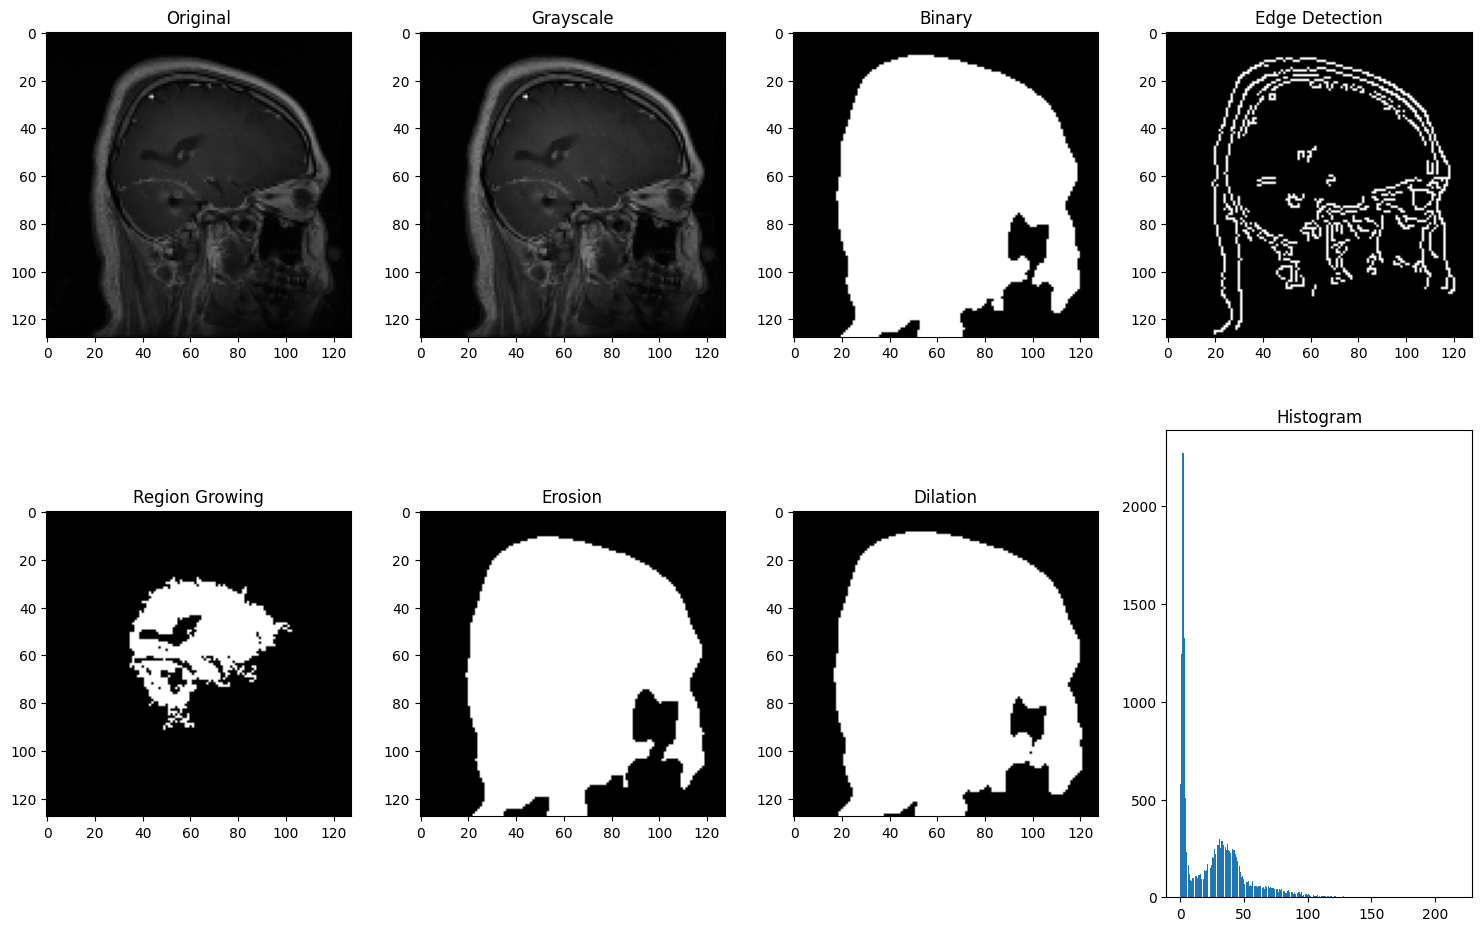

In [ ]:
sample_image = None

for cls in classes:

    folder = os.path.join(DATASET_PATH, 'Training', cls)

    img_name = os.listdir(folder)[0]

    sample_image = os.path.join(folder, img_name)

    break

processed = preprocess_image(sample_image)

edges = edge_detection(processed['gray'])

region = region_growing(processed['gray'], (64,64))

erosion, dilation = morphology(processed['binary'])

plt.figure(figsize=(15,10))

plt.subplot(2,4,1)
plt.imshow(cv2.cvtColor(processed['original'], cv2.COLOR_BGR2RGB))
plt.title('Original')

plt.subplot(2,4,2)
plt.imshow(processed['gray'], cmap='gray')
plt.title('Grayscale')

plt.subplot(2,4,3)
plt.imshow(processed['binary'], cmap='gray')
plt.title('Binary')

plt.subplot(2,4,4)
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection')

plt.subplot(2,4,5)
plt.imshow(region, cmap='gray')
plt.title('Region Growing')

plt.subplot(2,4,6)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')

plt.subplot(2,4,7)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')

plt.subplot(2,4,8)
plt.hist(processed['gray'].ravel(), bins=256)
plt.title('Histogram')

plt.tight_layout()
plt.show()

In [ ]:
X = []
y = []

label_map = {
    'glioma':0,
    'meningioma':1,
    'notumor':2,
    'pituitary':3
}

for cls in classes:

    folder = os.path.join(DATASET_PATH, 'Training', cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            processed = preprocess_image(img_path)

            img = processed['gray']

            img = img / 255.0

            X.append(img)

            y.append(label_map[cls])

        except:
            pass

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(X.shape)

(5600, 128, 128, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.6759 - loss: 0.7987 - val_accuracy: 0.7768 - val_loss: 0.5162
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8261 - loss: 0.4655 - val_accuracy: 0.8500 - val_loss: 0.3871
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8621 - loss: 0.3694 - val_accuracy: 0.8696 - val_loss: 0.3401
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8848 - loss: 0.3138 - val_accuracy: 0.8946 - val_loss: 0.2712
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9176 - loss: 0.2296 - val_accuracy: 0.8929 - val_loss: 0.2804
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9362 - loss: 0.1727 - val_accuracy: 0.9259 - val_loss: 0.2080
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9589 - loss: 0.1186 - val_accuracy: 0.9339 - val_loss: 0.2122
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9547 - loss: 0.1221 - val_accu

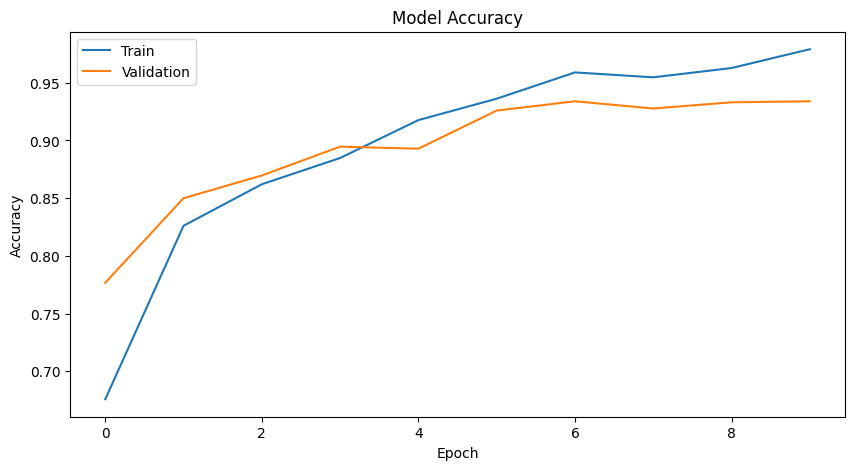

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print('Test Accuracy:', acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 569ms/step - accuracy: 0.9339 - loss: 0.2395
Test Accuracy: 0.9339285492897034


35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step


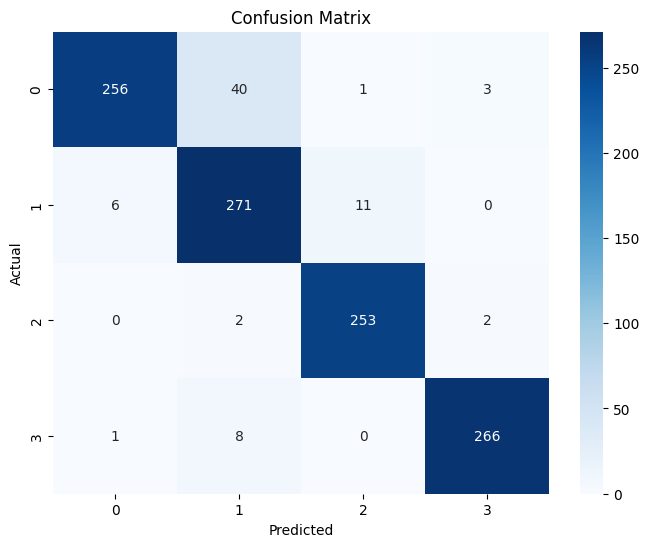

In [ ]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/brain_tumor_model.h5')

print('Model Saved Successfully!')

Model Saved Successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras import models

from google.colab import drive

drive.mount('/content/drive')

model = models.load_model(
    '/content/drive/MyDrive/brain_tumor_model.h5'
)

print('Model loaded successfully! No need to retrain.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully! No need to retrain.


In [ ]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']


def predict_image(img_path):

    processed = preprocess_image(img_path)

    img = processed['gray']

    img = img / 255.0

    img = img.reshape(1, IMG_SIZE, IMG_SIZE, 1)

    prediction = model.predict(img)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    plt.imshow(processed['gray'], cmap='gray')

    plt.title(
        f'Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.2f}'
    )

    plt.axis('off')

    plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 308ms/step

Overall Accuracy: 93.39%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.85      0.91       300
  meningioma       0.84      0.94      0.89       288
     notumor       0.95      0.98      0.97       257
   pituitary       0.98      0.97      0.97       275

    accuracy                           0.93      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.93      0.93      1120


Confusion Matrix:

[[256  40   1   3]
 [  6 271  11   0]
 [  0   2 253   2]
 [  1   8   0 266]]


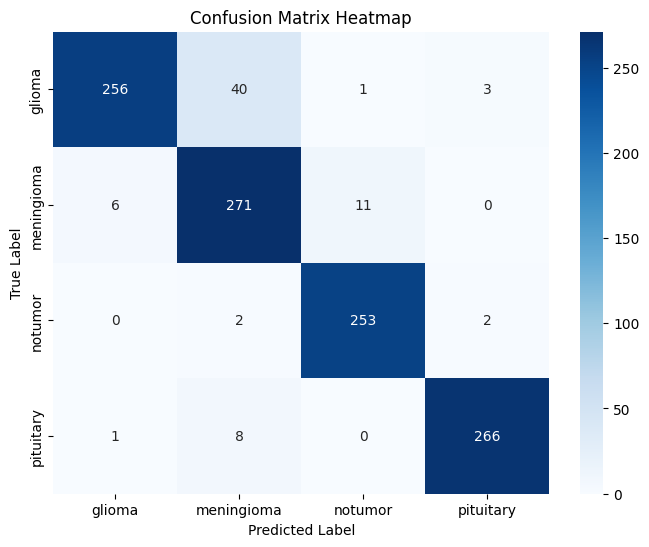

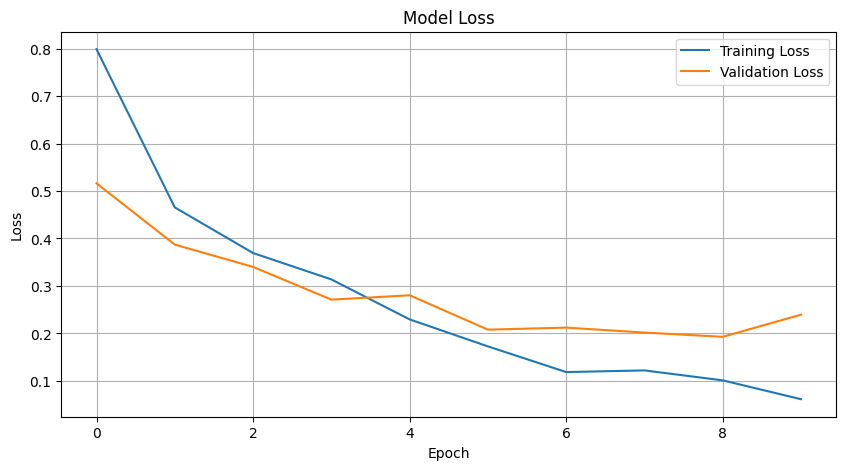

In [ ]:
# ================================
# Precision, Recall, F1-Score
# Confusion Matrix + Heatmap
# ================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predict Test Data
# -----------------------------
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

# -----------------------------
# Classification Report
# -----------------------------
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print("\nClassification Report:\n")
print(report)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# -----------------------------
# Heatmap of Confusion Matrix
# -----------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix Heatmap')

plt.xlabel('Predicted Label')

plt.ylabel('True Label')

plt.show()
# ================================
# Training & Validation Loss Graph
# ================================

import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

Saving Te-me_2.jpg to Te-me_2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


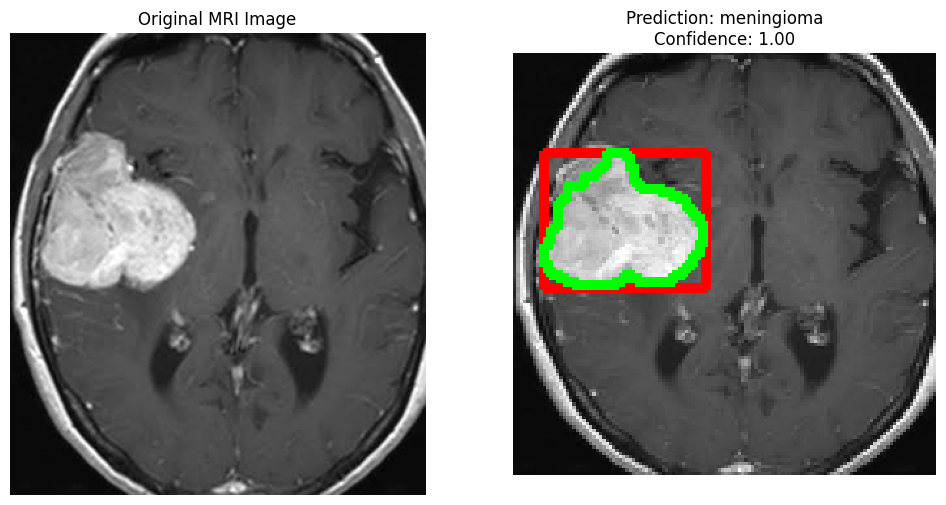

In [ ]:
# Updated Prediction Function with Tumor Highlighting

import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_image(img_path):

    # Read image
    img = cv2.imread(img_path)

    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    resized = cv2.resize(img, (128,128))

    # Convert to grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # Normalize
    normalized = gray / 255.0

    # CNN input
    input_img = normalized.reshape(1,128,128,1)

    # Prediction
    prediction = model.predict(input_img)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction)

    # -------------------------------
    # Tumor Segmentation
    # -------------------------------

    # Blur image
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold
    _, thresh = cv2.threshold(
        blur,
        160,
        255,
        cv2.THRESH_BINARY
    )

    # Morphological operations
    kernel = np.ones((3,3), np.uint8)

    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    thresh = cv2.dilate(
        thresh,
        kernel,
        iterations=1
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    segmented = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    # Draw tumor boundary
    for cnt in contours:

        area = cv2.contourArea(cnt)

        if area > 200:

            x, y, w, h = cv2.boundingRect(cnt)

            cv2.rectangle(
                segmented,
                (x,y),
                (x+w, y+h),
                (255,0,0),
                2
            )

            cv2.drawContours(
                segmented,
                [cnt],
                -1,
                (0,255,0),
                2
            )

    # -------------------------------
    # Display Results
    # -------------------------------

    plt.figure(figsize=(12,6))

    # Original Image
    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title('Original MRI Image')
    plt.axis('off')

    # Tumor Segmentation
    plt.subplot(1,2,2)
    plt.imshow(segmented)
    plt.title(
        f'Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.2f}'
    )
    plt.axis('off')

    plt.show()
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():

    predict_image(filename)